In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/aapl_features.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,id,ticker,open,high,low,close,volume,returns,log_returns,volatility,MA20,MA50
0,2023-03-15,50,AAPL,148.894,150.923,147.643,150.666,77167900,0.002615,0.002612,0.015158,148.02275,142.48100
1,2023-03-16,51,AAPL,149.849,154.084,149.337,153.483,76161100,0.018697,0.018524,0.015424,148.04835,143.09100
2,2023-03-17,52,AAPL,153.710,154.360,151.937,152.646,98944600,-0.005453,-0.005468,0.015282,148.11185,143.65890
3,2023-03-20,53,AAPL,152.715,155.423,151.809,155.009,73641400,0.015480,0.015362,0.015507,148.35065,144.30040
4,2023-03-21,54,AAPL,154.931,156.979,154.163,156.861,73938300,0.011948,0.011877,0.014134,148.88245,144.88848


In [24]:
signal = df["returns"].dropna()

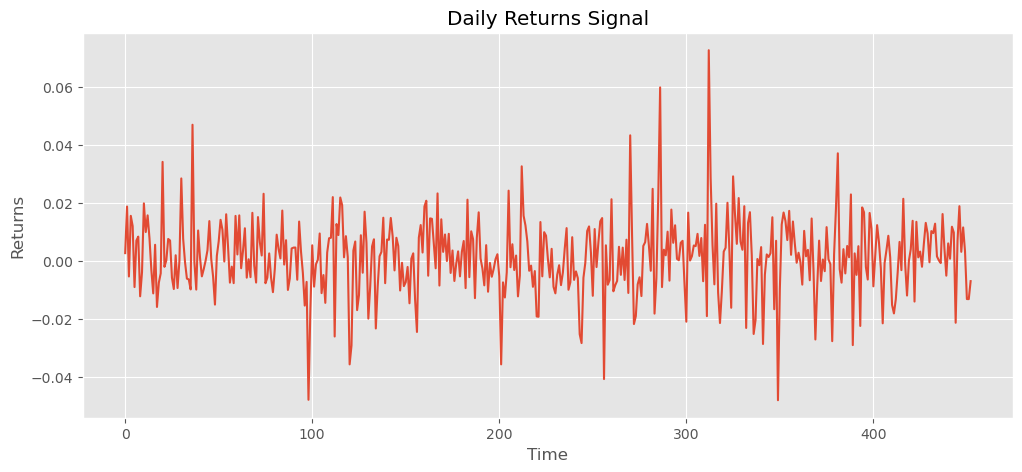

In [25]:
plt.figure(figsize=(12,5))
plt.plot(signal)
plt.title("Daily Returns Signal")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.show()

In [26]:
from scipy.fft import fft
from scipy.fft import fftfreq

In [27]:
N = len(signal)

fft_values = fft(signal)

frequencies = fftfreq(N)

In [28]:
power = np.abs(fft_values)

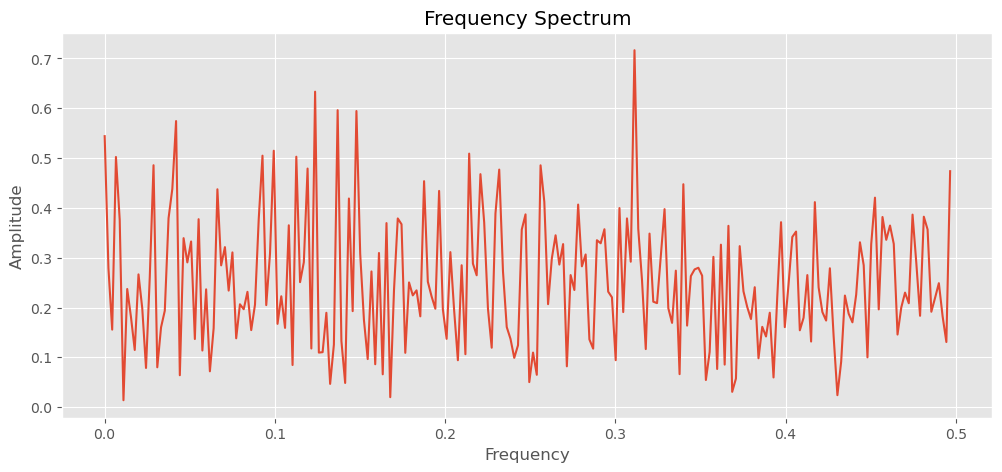

In [29]:
plt.figure(figsize=(12,5))

plt.plot(frequencies[:N//2],
         power[:N//2])

plt.title("Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [30]:
indices = np.argsort(power)[-10:]

dominant_freqs = frequencies[indices]

dominant_power = power[indices]

for f, p in zip(dominant_freqs, dominant_power):
    print(f, p)

-0.04194260485651214 0.5742501056078949
0.04194260485651214 0.5742501056078949
0.1479028697571744 0.5943629876179903
-0.1479028697571744 0.5943629876179903
-0.1368653421633554 0.5960899448036865
0.1368653421633554 0.5960899448036865
-0.12362030905077262 0.63320648291489
0.12362030905077262 0.63320648291489
-0.31125827814569534 0.7164198516979564
0.31125827814569534 0.7164198516979564


In [31]:
positive_freq = frequencies[frequencies > 0]

positive_power = power[frequencies > 0]

periods = 1 / positive_freq

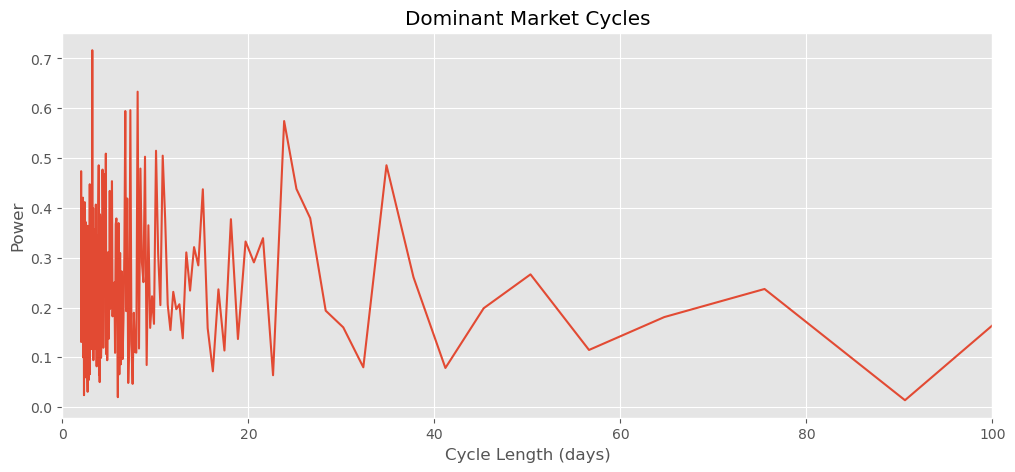

In [32]:
plt.figure(figsize=(12,5))

plt.plot(periods, positive_power)

plt.xlim(0,100)

plt.xlabel("Cycle Length (days)")
plt.ylabel("Power")

plt.title("Dominant Market Cycles")

plt.show()

In [34]:
freq = fftfreq(len(signal))
amp = np.abs(fft_values)

In [35]:
dominant_frequency = freq[np.argmax(amp)]

print("Dominant Frequency:", dominant_frequency)

Dominant Frequency: 0.31125827814569534


In [36]:
spectral_energy = np.sum(amp**2)

print("Spectral Energy:", spectral_energy)

Spectral Energy: 36.051417142267965


In [38]:
from scipy.stats import entropy

In [39]:
power = amp / np.sum(amp)

spectral_entropy = entropy(power)

print("Spectral Entropy:", spectral_entropy)

Spectral Entropy: 5.977280863528537


In [40]:
frequency_centroid = np.sum(freq * amp) / np.sum(amp)

print("Frequency Centroid:", frequency_centroid)

Frequency Centroid: 1.567472023299068e-17


In [41]:
spectral_variance = np.sum(
    ((freq - frequency_centroid)**2) * amp
) / np.sum(amp)

print("Spectral Variance:", spectral_variance)

Spectral Variance: 0.0809304668813268


In [42]:
spectral_features = {
    "dominant_frequency": dominant_frequency,
    "spectral_energy": spectral_energy,
    "spectral_entropy": spectral_entropy,
    "frequency_centroid": frequency_centroid,
    "spectral_variance": spectral_variance
}

spectral_features

{'dominant_frequency': np.float64(0.31125827814569534),
 'spectral_energy': np.float64(36.051417142267965),
 'spectral_entropy': np.float64(5.977280863528537),
 'frequency_centroid': np.float64(1.567472023299068e-17),
 'spectral_variance': np.float64(0.0809304668813268)}

In [43]:
spectral_df = pd.DataFrame([spectral_features])

spectral_df

,dominant_frequency,spectral_energy,spectral_entropy,frequency_centroid,spectral_variance
0,0.311258,36.051417,5.977281,1.567472e-17,0.08093


In [44]:
spectral_df.to_csv(
    "../data/spectral_features.csv",
    index=False
)